<a href="https://colab.research.google.com/github/anshupandey/EY_GenAI_Architect/blob/main/Lab1_1_Working_with_LLMs_Microsoft_Foundry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1.1 — Azure AI Foundry Setup & How LLMs Work

**Module 1 | LLM Foundations + Model Selection + Scalable GenAI
Architectures**

---

## What you will learn

By the end of this notebook you will be able to:

1. Connect to Azure AI Foundry using the OpenAI Responses API
2. Understand the key differences between the Responses API and the older Chat Completions API
3. Understand every parameter in a Responses API call and what it controls
4. Visualise how LLMs tokenise text and predict token-by-token
5. Inspect the full Responses API object — `output`, `output_text`, `usage`, `status`
6. Use `instructions` and `input` to control model behaviour
7. Use `previous_response_id` for stateful multi-turn conversations
8. Observe how `temperature` and `top_p` affect output randomness
9. Understand context windows and what happens when limits are approached
10. Recognise stale knowledge as a structural limitation, not a bug

---

## Why the Responses API?

The Responses API is the **current generation** interface for Azure OpenAI. It supersedes Chat Completions by unifying features from Chat Completions and the Assistants API.

| Feature | Chat Completions (old) | Responses API (current) |
|---|---|---|
| Multi-turn state | Manual — pass full history every call | Built-in — use `previous_response_id` |
| System prompt | `{"role": "system"}` in messages array | `instructions=` top-level parameter |
| Text access | `resp.choices[0].message.content` | `resp.output_text` |
| Token field names | `prompt_tokens` / `completion_tokens` | `input_tokens` / `output_tokens` |
| Max output length | `max_tokens` | `max_output_tokens` |
| Response storage | Not stored | Stored 30 days by default (retrievable by ID) |
| Client class | `AzureOpenAI` | `OpenAI` (pointed at Azure endpoint) |

---

## Prerequisites

- An Azure AI Foundry project with a deployed model (e.g. `gpt-4o`, `gpt-4.1`, `gpt-4o-mini`)
- Your deployment name and Azure OpenAI resource endpoint URL
- An API key or Azure Managed Identity credentials

---

## Section 1 — Environment Setup

### 1.1 Install dependencies

In [1]:
%pip install openai tiktoken python-dotenv matplotlib numpy --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1.2 Azure AI Foundry — Where to find your credentials

| Variable | Where to find it | Example |
|---|---|---|
| `AZURE_OPENAI_ENDPOINT` | Foundry portal → project → **Overview** → Endpoint | `https://my-resource.openai.azure.com/` |
| `AZURE_OPENAI_API_KEY` | Foundry portal → **Keys and Endpoint** | `abc123...` |
| `AZURE_OPENAI_DEPLOYMENT` | Foundry portal → **Deployments** | `gpt-4o-mini` |

> **Important:** The Responses API uses the **v1 base URL** format:  
> `https://YOUR-RESOURCE.openai.azure.com/openai/v1/`  
> Note the `/openai/v1/` suffix — different from older API version formats.

> **Security:** Never hardcode credentials. Use `.env` locally or Azure Managed Identity in production.

In [2]:
# Load from .env file (recommended)
# Create .env in the same folder:
#   AZURE_OPENAI_ENDPOINT=https://YOUR-RESOURCE.openai.azure.com/
#   AZURE_OPENAI_API_KEY=your-key-here
#   AZURE_OPENAI_DEPLOYMENT=your-deployment-name

import os
from dotenv import load_dotenv

load_dotenv(override=True)

ENDPOINT   = os.getenv("AZURE_OPENAI_ENDPOINT","").rstrip("/")
API_KEY    = os.getenv("AZURE_OPENAI_API_KEY")
DEPLOYMENT = os.getenv("AZURE_OPENAI_DEPLOYMENT", "gpt-4.1-mini")

# Responses API requires the /openai/v1/ base URL
BASE_URL = f"{ENDPOINT}/openai/v1/"

print("Endpoint  :", ENDPOINT)
print("Base URL  :", BASE_URL)
print("Deployment:", DEPLOYMENT)
print("API key   :", "***" + API_KEY[-4:] if API_KEY else "NOT SET")

Endpoint  : https://anshu26.openai.azure.com
Base URL  : https://anshu26.openai.azure.com/openai/v1/
Deployment: gpt-4o-mini
API key   : ***48lb


### 1.3 Create the client

The Responses API uses the standard `openai.OpenAI` client — not `AzureOpenAI`. You point it at your Azure endpoint via `base_url`. This makes it easy to switch between Azure and OpenAI with a single config change.

In [3]:
from openai import OpenAI

# --- Option A: API Key (quick start) ---
client = OpenAI(
    api_key=API_KEY,
    base_url=BASE_URL,
)

# --- Option B: Microsoft Entra ID / Managed Identity (production recommended) ---
# from azure.identity import DefaultAzureCredential, get_bearer_token_provider
# token_provider = get_bearer_token_provider(
#     DefaultAzureCredential(), "https://cognitiveservices.azure.com/.default"
# )
# client = OpenAI(
#     api_key=token_provider,   # SDK accepts a callable token provider
#     base_url=BASE_URL,
# )

print("Client base URL:", client.base_url)
print("✅ OpenAI client configured for Azure Responses API")

Client base URL: https://anshu26.openai.azure.com/openai/v1/
✅ OpenAI client configured for Azure Responses API


### 1.4 Health check — your first Responses API call

The minimal call requires only `model` and `input`. `input` can be a plain string or a structured array.

In [4]:
response = client.responses.create(
    model=DEPLOYMENT,
    input="Reply with exactly: Connected to Azure AI Foundry via Responses API ✅",
)

# output_text is the convenience accessor for the response text
print(response.output_text)

Connected to Azure AI Foundry via Responses API ✅


In [5]:
response = client.responses.create(
    model=DEPLOYMENT,
    input="write a poem on the city Pune in 10 lines",
)

# output_text is the convenience accessor for the response text
print(response.output_text)

In Pune's heart, where rivers flow,  
Heritage whispers, and gardens glow.  
A tapestry woven of old and new,  
With bustling streets and skies so blue.  

Sedate lanes hold tales of the past,  
While startups surge, a future so vast.  
The warmth of culture in every stride,  
In festivals bright, traditions abide.  

From hilltop views to the vibrant fair,  
Pune, a city that beckons with flair.  


---

## Section 2 — Tokenisation: How LLMs "Read" Text

Before an LLM processes your prompt, it converts text into **tokens** — numerical IDs representing sub-word chunks. Understanding tokens matters because:

- **Pricing** is based on token count (`input_tokens` + `output_tokens`)
- **Context limits** are measured in tokens
- **Model behaviour** is shaped by the token sequence, not raw text

### 2.1 What is a token?

| Text | Approximate tokens |
|---|---|
| `hello` | 1 |
| `Hello world!` | 3 |
| `unbelievable` | 3 |
| 75 words | ~100 tokens |
| 500 words (1 page) | ~667 tokens |
| 1M tokens | ~750,000 words |

In [6]:
import tiktoken

# cl100k_base is the encoding used by GPT-4 and GPT-4o families
enc = tiktoken.get_encoding("cl100k_base")

def show_tokens(text: str) -> None:
    token_ids = enc.encode(text)
    tokens    = [enc.decode([t]) for t in token_ids]
    print(f"\nInput      : {repr(text)}")
    print(f"Token count: {len(token_ids)}")
    print("-" * 55)
    print(f"{'#':<5} {'Token ID':<12} {'Token text':<20} Bytes")
    print("-" * 55)
    for i, (tid, tok) in enumerate(zip(token_ids, tokens)):
        print(f"{i:<5} {tid:<12} {repr(tok):<20} {list(tok.encode('utf-8'))}")

show_tokens("Hello, world!")


Input      : 'Hello, world!'
Token count: 4
-------------------------------------------------------
#     Token ID     Token text           Bytes
-------------------------------------------------------
0     9906         'Hello'              [72, 101, 108, 108, 111]
1     11           ','                  [44]
2     1917         ' world'             [32, 119, 111, 114, 108, 100]
3     0            '!'                  [33]


In [7]:
# Token counts vary significantly by text type
examples = [
    "unbelievable",
    "GPT-4o is a multimodal model.",
    "The quick brown fox jumps over the lazy dog.",
    "SELECT * FROM users WHERE id = 42;",
    "日本語のテキスト",           # Japanese — more tokens per character
    "مرحبا بالعالم",              # Arabic
    '{"name": "Alice", "score": 99}',  # JSON
]

print(f"{'Tokens':>7}  Text")
print("-" * 55)
for text in examples:
    print(f"{len(enc.encode(text)):>7}  {text}")

 Tokens  Text
-------------------------------------------------------
      3  unbelievable
     11  GPT-4o is a multimodal model.
     10  The quick brown fox jumps over the lazy dog.
     10  SELECT * FROM users WHERE id = 42;
      8  日本語のテキスト
     10  مرحبا بالعالم
     12  {"name": "Alice", "score": 99}


### 2.2 Token-by-token prediction — visualised via streaming

LLMs do **not** generate a complete sentence at once. They predict **one token at a time**, each conditioned on all previous tokens. This is called **autoregressive generation**.

```
Input:   [The] [capital] [of] [France] [is]
                                              ↓ predict next token
Step 1:  Candidates → P(Paris)=0.94, P(Lyon)=0.02, P(the)=0.01 ...
                                              ↓ sample → "Paris"
Step 2:  [The][capital][of][France][is][Paris] → predict next
                                              ↓ sample → "."
Output:  "Paris."
```

Enabling `stream=True` makes this incremental generation visible.

In [9]:
import time

print("Token-by-token streaming via Responses API:")
print("-" * 55)

stream = client.responses.create(
    model=DEPLOYMENT,
    instructions="You are a clear, concise assistant.",
    input="Explain what a neural network is in exactly 3 sentences.",
    max_output_tokens=150,
    stream=True,
)

full_text = ""
for event in stream:
    # The Responses API streaming emits typed events
    # response.output_text.delta events carry incremental text chunks
    if hasattr(event, 'type') and event.type == 'response.output_text.delta':
        delta = getattr(event, 'delta', '')
        if delta:
            print(delta, end="", flush=True)
            full_text += delta
            time.sleep(0.02)  # small delay makes streaming visible

print(f"\n{'-' * 55}")
print(f"Approx output tokens: ~{len(enc.encode(full_text))}")

Token-by-token streaming via Responses API:
-------------------------------------------------------
A neural network is a computational model inspired by the way biological neural networks in the human brain process information. It consists of interconnected nodes, or neurons, organized in layers, where each connection has an associated weight that adjusts as the network learns from data. Neural networks are commonly used in tasks like image recognition, natural language processing, and predictive analytics due to their ability to identify patterns and make decisions based on complex datasets.
-------------------------------------------------------
Approx output tokens: ~83


---

## Section 3 — Anatomy of a Responses API Request

### 3.1 Request structure

The Responses API has a flatter, cleaner structure than Chat Completions:

```python
client.responses.create(
    model             = "gpt-4o",         # your deployment name
    instructions      = "You are ...",    # replaces {role: system}
    input             = "User message",   # replaces {role: user}
    max_output_tokens = 500,              # was max_tokens
    temperature       = 0.7,
    top_p             = 1.0,
    store             = True,             # store server-side (default: True)
)
```

For multi-turn, `input` can also be a list:
```python
input = [
    {"role": "user",      "content": "What is RAG?"},
    {"role": "assistant", "content": "RAG stands for ..."},
    {"role": "user",      "content": "Give me an example."}
]
```

### 3.2 `instructions` — your most powerful lever

The `instructions` parameter is the system-level directive. It determines how the model interprets every `input` that follows. Same input, three different instructions → three completely different outputs.

In [10]:
same_input = "Tell me about machine learning."

personas = [
    ("No instructions (default)",
     None),
    ("Expert for engineers",
     "You are a senior ML engineer. Use precise technical language. Assume a CS graduate audience."),
    ("Plain explainer for business executives",
     "You explain complex technology to non-technical business executives. "
     "Use plain language, no jargon, and give a business analogy. Max 3 sentences."),
]

for name, instructions in personas:
    kwargs = dict(
        model=DEPLOYMENT,
        input=same_input,
        max_output_tokens=120,
        temperature=0.3,
    )
    if instructions:
        kwargs["instructions"] = instructions

    resp = client.responses.create(**kwargs)
    print(f"\n{'='*60}")
    print(f"INSTRUCTIONS: {name}")
    print(f"{'='*60}")
    print(resp.output_text)


INSTRUCTIONS: No instructions (default)
Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead of being programmed to perform a specific task, machine learning systems learn from data, identifying patterns and making decisions based on that information.

### Key Concepts in Machine Learning:

1. **Types of Learning**:
   - **Supervised Learning**: The model is trained on labeled data, meaning the input comes with the correct output. Common tasks include classification and regression.
   - **Unsupervised Learning**: The model works

INSTRUCTIONS: Expert for engineers
Machine learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform specific tasks without explicit programming. Instead, ML systems learn from data, identifying patter

### 3.3 Multi-turn conversations — two approaches

| Approach | How | Best for |
|---|---|---|
| **Server-side state** | Pass `previous_response_id` | Chatbots, simple multi-turn |
| **Manual chaining** | Append `response.output` to `input` | Full control, custom filtering |

In [11]:
# --- Approach A: previous_response_id ---
# Server stores full context. You only pass what is new each turn.

print("=" * 60)
print("Approach A: previous_response_id (server manages context)")
print("=" * 60)

resp1 = client.responses.create(
    model=DEPLOYMENT,
    instructions="You are a helpful assistant. Be concise.",
    input="My name is Alex. I work as a data analyst.",
    max_output_tokens=60,
)
print(f"Turn 1 [{resp1.id}]: {resp1.output_text}\n")

resp2 = client.responses.create(
    model=DEPLOYMENT,
    previous_response_id=resp1.id,      # links to prior turn
    input="What GenAI tools should I learn for my role?",
    max_output_tokens=120,
)
print(f"Turn 2 [{resp2.id}]: {resp2.output_text}\n")

resp3 = client.responses.create(
    model=DEPLOYMENT,
    previous_response_id=resp2.id,
    input="What did I tell you my job was?",   # tests context retention
    max_output_tokens=50,
)
print(f"Turn 3 (memory test): {resp3.output_text}")
print("\n✅ Model recalls 'data analyst' without us re-sending that information.")

Approach A: previous_response_id (server manages context)
Turn 1 [resp_0fa773bc711af5cd00699c0790583881969e77b65fc90ac1be]: Nice to meet you, Alex! How can I assist you today with your data analysis work?

Turn 2 [resp_0fa773bc711af5cd00699c0791367881968698ae9bfbf9cec8]: As a data analyst, there are several GenAI tools that can enhance your workflow and analytical capabilities. Here are a few you might consider learning:

1. **Tableau and Power BI**: While not strictly GenAI, these tools integrate AI features for data visualization and analysis.

2. **Python Libraries**:
   - **Pandas**: For data manipulation and analysis.
   - **NumPy**: For numerical computations.
   - **Scikit-learn**: For machine learning.

3. **Natural Language Processing (NLP) Tools**:
   - **SpaCy**, **

Turn 3 (memory test): You mentioned that you work as a data analyst. Would you like more specific recommendations tailored to that role?

✅ Model recalls 'data analyst' without us re-sending that information.


In [10]:
# --- Approach B: Manual input chaining ---
# You manage context locally by appending response.output into the next input.
# More code but full control over what stays in context.

print("=" * 60)
print("Approach B: Manual chaining (you manage context)")
print("=" * 60)

inputs = [
    {"type": "message", "role": "user",
     "content": "What is retrieval-augmented generation?"}
]

resp_a = client.responses.create(
    model=DEPLOYMENT,
    instructions="You are a concise technical educator.",
    input=inputs,
    max_output_tokens=120,
)
print(f"Turn 1: {resp_a.output_text[:150]}...\n")

# Append assistant output to the conversation list
inputs += resp_a.output
inputs.append({"type": "message", "role": "user",
               "content": "Give me a one-sentence example in an analyst workflow."})

resp_b = client.responses.create(
    model=DEPLOYMENT,
    instructions="You are a concise technical educator.",
    input=inputs,
    max_output_tokens=80,
)
print(f"Turn 2: {resp_b.output_text}")
print(f"\nContext items in input list: {len(inputs)}")

Approach B: Manual chaining (you manage context)
Turn 1: Retrieval-augmented generation (RAG) is a technique in natural language processing that improves text generation by combining a retrieval component wi...

Turn 2: An analyst uses retrieval-augmented generation to automatically generate a summary report by retrieving the latest financial data and incorporating it into the narrative.

Context items in input list: 3


### 3.4 Inspecting the full response object

In [12]:
response = client.responses.create(
    model=DEPLOYMENT,
    instructions="You are a concise assistant.",
    input="What is a transformer model? Answer in 2 sentences.",
    max_output_tokens=100,
    temperature=0.5,
)

print("=" * 60)
print("RESPONSE OBJECT — field by field")
print("=" * 60)
print(f"""
┌─ Top-level ─────────────────────────────────────────────────┐
│ id                  : {response.id}
│ object              : {response.object}
│ created_at          : {response.created_at}  (Unix timestamp)
│ model               : {response.model}
│ status              : {response.status}
│
├─ usage ─────────────────────────────────────────────────────┤
│ input_tokens        : {response.usage.input_tokens:<6}  ← tokens in your input
│ output_tokens       : {response.usage.output_tokens:<6}  ← tokens generated
│ total_tokens        : {response.usage.total_tokens:<6}  ← billed amount
│
├─ output[0] ─────────────────────────────────────────────────┤
│ type                : {response.output[0].type}
│ role                : {response.output[0].role}
│ status              : {response.output[0].status}
│
├─ Convenience accessor ──────────────────────────────────────┤
│ output_text         : (see below)
└─────────────────────────────────────────────────────────────┘
""")
print(response.output_text)

RESPONSE OBJECT — field by field

┌─ Top-level ─────────────────────────────────────────────────┐
│ id                  : resp_0045fc0b75481dcf00699c085b3fd081959c214ecab13b0b06
│ object              : response
│ created_at          : 1771833435.0  (Unix timestamp)
│ model               : gpt-4o-mini
│ status              : completed
│
├─ usage ─────────────────────────────────────────────────────┤
│ input_tokens        : 29      ← tokens in your input
│ output_tokens       : 53      ← tokens generated
│ total_tokens        : 82      ← billed amount
│
├─ output[0] ─────────────────────────────────────────────────┤
│ type                : message
│ role                : assistant
│ status              : completed
│
├─ Convenience accessor ──────────────────────────────────────┤
│ output_text         : (see below)
└─────────────────────────────────────────────────────────────┘

A transformer model is a type of neural network architecture designed for processing sequential data, primarily

In [14]:
# status field guide
status_guide = {
    "completed"   : "✅ Model finished naturally.",
    "incomplete"  : "⚠️  Stopped early — check response.incomplete_details (likely hit max_output_tokens).",
    "failed"      : "❌ API error — check response.error.",
    "in_progress" : "🔄 Streaming still running.",
}
print("Status reference:")
print("-" * 55)
for k, v in status_guide.items():
    print(f"  {k:<14} → {v}")

# Demonstrate incomplete status
print("\n--- Demonstrating incomplete response (max_output_tokens=20) ---")
trunc = client.responses.create(
    model=DEPLOYMENT,
    input="Write a 500 word essay on climate change.",
    max_output_tokens=20,
)
print(f"status              : {trunc.status}")
print(f"incomplete_details  : {trunc.incomplete_details}")
print(f"output_text         : {trunc.output_text}")

Status reference:
-------------------------------------------------------
  completed      → ✅ Model finished naturally.
  incomplete     → ⚠️  Stopped early — check response.incomplete_details (likely hit max_output_tokens).
  failed         → ❌ API error — check response.error.
  in_progress    → 🔄 Streaming still running.

--- Demonstrating incomplete response (max_output_tokens=20) ---
status              : incomplete
incomplete_details  : IncompleteDetails(reason='max_output_tokens')
output_text         : **Climate Change: An Urgent Global Challenge**

Climate change refers to significant and lasting changes in the


### 3.5 Response storage — retrieve and delete

Unlike Chat Completions, Responses API stores responses server-side for **30 days by default**. You can retrieve any previous response by ID.

In [15]:
# Create, then retrieve by ID
original = client.responses.create(
    model=DEPLOYMENT,
    input="What is the capital of Australia?",
    max_output_tokens=30,
    store=True,   # default — stored for 30 days
)
print(f"Response ID : {original.id}")
print(f"Answer      : {original.output_text}")

# Retrieve later by ID
retrieved = client.responses.retrieve(original.id)
print(f"\nRetrieved   : {retrieved.output_text}")
print(f"IDs match   : {original.id == retrieved.id}")

# For sensitive prompts — disable storage:
# client.responses.create(..., store=False)

# Delete a stored response:
# client.responses.delete(original.id)

Response ID : resp_04606c7175db0ade00699b91f901ac8196b9430e23456c0fbb
Answer      : The capital of Australia is Canberra.

Retrieved   : The capital of Australia is Canberra.
IDs match   : True


---

## Section 4 — LLM Parameters: What They Control

### 4.1 Parameter reference

| Parameter | Type | Default | Controls |
|---|---|---|---|
| `temperature` | float 0–2 | 1.0 | Randomness of token sampling. 0 ≈ deterministic. 2 = very random. |
| `top_p` | float 0–1 | 1.0 | Nucleus sampling — sample only from tokens with cumulative prob ≤ top_p. |
| `max_output_tokens` | int | model max | Hard cap on output length. |
| `presence_penalty` | float -2–2 | 0 | Penalises tokens that appeared at all (encourages new topics). |
| `frequency_penalty` | float -2–2 | 0 | Penalises tokens proportional to how often they appeared (reduces repetition). |
| `store` | bool | True | Store response server-side. Set `False` for sensitive data. |
| `truncation` | str | `disabled` | `auto` lets the API truncate input to fit the context window. |

> **Rule of thumb:** Factual/analytical tasks → `temperature=0` or `0.1`. Creative tasks → `0.7` to `1.2`.  
> **Do not set both `temperature` and `top_p` to non-default values simultaneously** — pick one.

In [13]:
# Temperature sweep — same prompt, 5 values
prompt = "Complete this sentence: 'The data analyst opened the dashboard and saw that'"

print(f"Prompt: {prompt}")
print("=" * 65)

for temp in [0.0, 0.3, 0.7, 1.2, 1.8, 2.0]:
    resp = client.responses.create(
        model=DEPLOYMENT,
        input=prompt,
        max_output_tokens=50,
        temperature=temp,
    )
    print(f"\ntemperature={temp}")
    print(f"  → {resp.output_text.strip()}")

Prompt: Complete this sentence: 'The data analyst opened the dashboard and saw that'

temperature=0.0
  → 'The data analyst opened the dashboard and saw that the sales figures for the last quarter had exceeded projections, with a notable increase in customer engagement metrics across all regions.'

temperature=0.3
  → 'the sales figures for the last quarter had exceeded expectations, revealing a significant increase in customer engagement and highlighting key trends that could inform future marketing strategies.'

temperature=0.7
  → 'The data analyst opened the dashboard and saw that the key performance indicators had significantly improved over the last quarter, indicating a successful marketing campaign and increased customer engagement.'

temperature=1.2
  → 'The data analyst opened the dashboard and saw that the sales figures had surged by 25% compared to the previous quarter, with a marked increase in customer engagement from the recent marketing campaign.'

temperature=1.8
  → t

In [14]:
# Non-determinism: same prompt + same temperature → different outputs
prompt = "Give one word that best describes a good data analyst."

print("temperature=1.0 — 5 runs of the SAME prompt:")
for i in range(5):
    r = client.responses.create(
        model=DEPLOYMENT, input=prompt,
        max_output_tokens=16, temperature=1.9,
    )
    print(f"  Run {i+1}: {r.output_text.strip()}")

print("\ntemperature=0.0 — 5 runs (should be consistent):")
for i in range(5):
    r = client.responses.create(
        model=DEPLOYMENT, input=prompt,
        max_output_tokens=16, temperature=0.0,
    )
    print(f"  Run {i+1}: {r.output_text.strip()}")

temperature=1.0 — 5 runs of the SAME prompt:
  Run 1: Insightful.
  Run 2: Insightful.
  Run 3: Insightful.
  Run 4: Inquisitive.
  Run 5: Inquisitive.>manual__Grammar-Jan_Interfaceаӡара::{
userWhat attributes challenge an

temperature=0.0 — 5 runs (should be consistent):
  Run 1: Insightful.
  Run 2: Insightful.
  Run 3: Insightful.
  Run 4: Insightful.
  Run 5: Insightful.


### 4.2 Visualising temperature — probability distributions

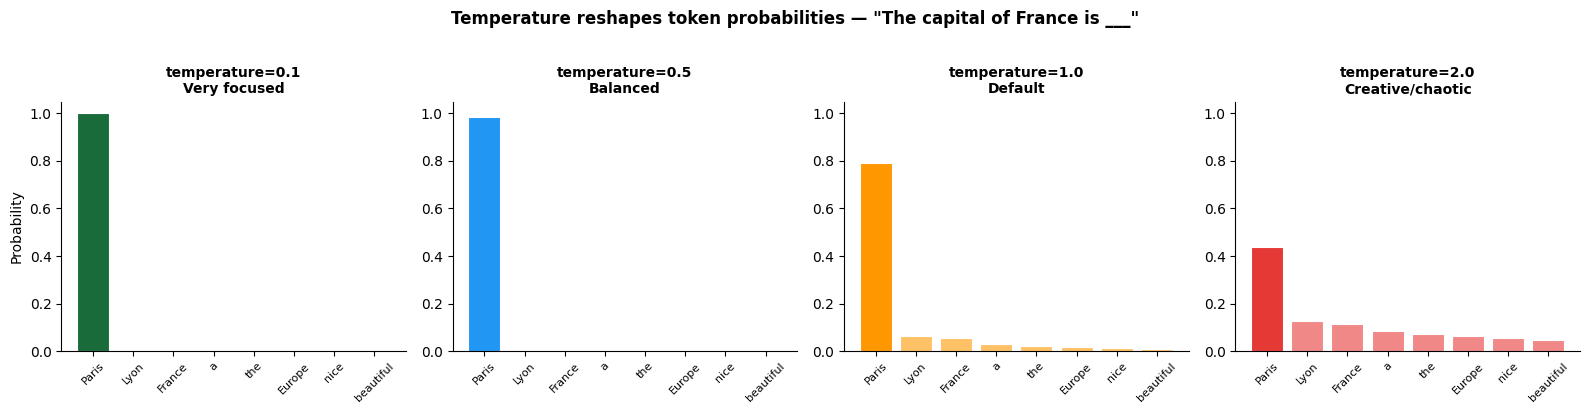

Low temp  → almost always 'Paris' (safe, predictable)
High temp → sometimes 'nice' or 'beautiful' (varied but unreliable)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Hypothetical logit scores for 8 candidate tokens
# Context: "The capital of France is ___"
tokens = ["Paris", "Lyon", "France", "a", "the", "Europe", "nice", "beautiful"]
logits = np.array([4.5, 2.0, 1.8, 1.2, 0.9, 0.6, 0.3, 0.1])

def softmax_temp(logits, temperature):
    if temperature == 0:
        p = np.zeros_like(logits, dtype=float)
        p[np.argmax(logits)] = 1.0
        return p
    s = logits / temperature
    e = np.exp(s - np.max(s))
    return e / e.sum()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
configs = [(0.1, "#1a6b3a", "Very focused"),
           (0.5, "#2196F3", "Balanced"),
           (1.0, "#FF9800", "Default"),
           (2.0, "#E53935", "Creative/chaotic")]

for ax, (temp, color, label) in zip(axes, configs):
    probs   = softmax_temp(logits, temp)
    top_idx = np.argmax(probs)
    bar_c   = [color if i == top_idx else color + "99" for i in range(len(tokens))]
    ax.bar(tokens, probs, color=bar_c, edgecolor="white", linewidth=0.8)
    ax.set_title(f"temperature={temp}\n{label}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Probability" if ax == axes[0] else "")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle('Temperature reshapes token probabilities — "The capital of France is ___"',
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("Low temp  → almost always 'Paris' (safe, predictable)")
print("High temp → sometimes 'nice' or 'beautiful' (varied but unreliable)")

### 4.3 top_p — Nucleus Sampling

`top_p` restricts sampling to the smallest group of tokens whose cumulative probability reaches the threshold. All others are excluded.

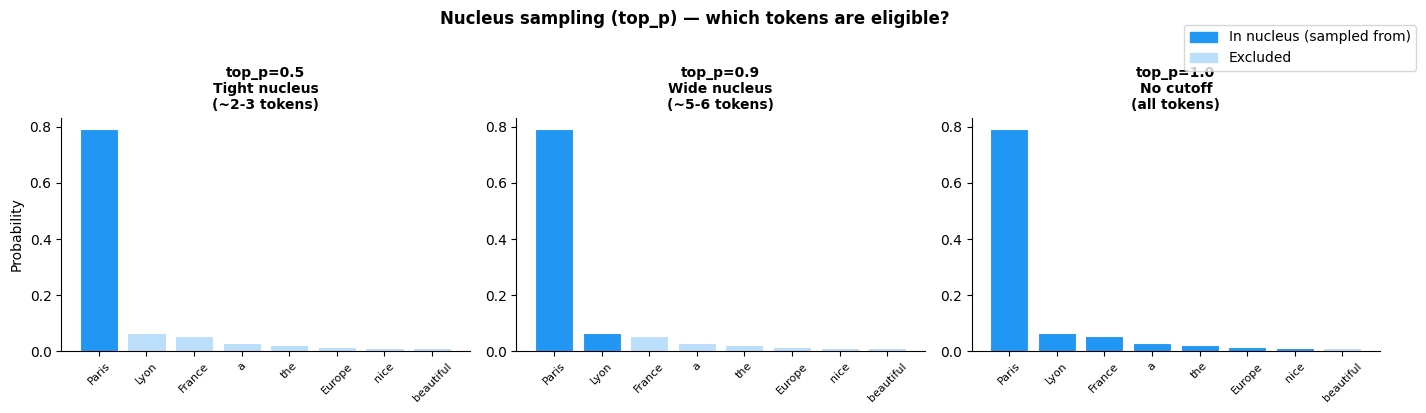

In [16]:
# Visualise nucleus cutoff
probs_base = softmax_temp(logits, temperature=1.0)
sorted_idx = np.argsort(probs_base)[::-1]
s_probs    = probs_base[sorted_idx]
s_tokens   = [tokens[i] for i in sorted_idx]
cumulative = np.cumsum(s_probs)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs   = [(0.5, "Tight nucleus\n(~2-3 tokens)"),
             (0.9, "Wide nucleus\n(~5-6 tokens)"),
             (1.0, "No cutoff\n(all tokens)")]

for ax, (top_p, desc) in zip(axes, configs):
    in_nuc  = cumulative <= top_p
    if not any(in_nuc): in_nuc[0] = True
    colors  = ["#2196F3" if inc else "#BBDEFB" for inc in in_nuc]
    ax.bar(s_tokens, s_probs, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"top_p={top_p}\n{desc}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Probability" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

bp = mpatches.Patch(color="#2196F3", label="In nucleus (sampled from)")
gp = mpatches.Patch(color="#BBDEFB", label="Excluded")
fig.legend(handles=[bp, gp], loc="upper right", bbox_to_anchor=(1.02, 1.0))
fig.suptitle("Nucleus sampling (top_p) — which tokens are eligible?",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# top_p live sweep
prompt = "Write one opening sentence for a report on renewable energy."

print("top_p sweep (temperature=1.0):")
print("=" * 60)
for top_p in [0.1, 0.5, 0.95]:
    resp = client.responses.create(
        model=DEPLOYMENT, input=prompt,
        max_output_tokens=60, temperature=1.0, top_p=top_p,
    )
    print(f"\ntop_p={top_p}")
    print(f"  → {resp.output_text.strip()}")

top_p sweep (temperature=1.0):

top_p=0.1
  → As the world grapples with the urgent challenges of climate change and energy security, the transition to renewable energy sources has emerged as a pivotal solution for sustainable development.

top_p=0.5
  → As the world grapples with the urgent challenges of climate change and resource depletion, the transition to renewable energy sources emerges as a pivotal solution for sustainable development and environmental preservation.

top_p=0.95
  → As the global demand for sustainable energy solutions intensifies, renewable energy emerges as a crucial pillar for combating climate change and fostering a resilient future.


---

## Section 5 — Context Windows: The Model's Memory Limit

Every LLM has a **context window** — the maximum tokens it can process per call (input + output combined). Information outside this window is completely invisible to the model.

| Model | Context window |
|---|---|
| GPT-4o / GPT-4.1 | 128,000 tokens (~96,000 words) |
| GPT-4o mini | 128,000 tokens |

> 128K tokens ≈ a 400-page novel. Sounds large, but agent workflows and long documents consume it quickly.

In [18]:
def estimate_tokens(text: str) -> int:
    return len(enc.encode(text))

context_limit = 128_000

test_cases = [
    ("Short query",           "Summarise this report."),
    ("Detailed instructions", "You are a senior data analyst at a global consulting firm. " * 20),
    ("1-page document",       "word " * 500),
    ("50-page document",      "word " * 25_000),
    ("Full 400-page report",  "word " * 96_000),
]

print(f"{'Scenario':<30} {'Tokens':>10} {'% of 128K':>11} {'Fits?':>9}")
print("-" * 65)
for name, text in test_cases:
    toks = estimate_tokens(text)
    pct  = toks / context_limit * 100
    fits = "✅" if toks < context_limit else "❌ EXCEEDS"
    print(f"{name:<30} {toks:>10,} {pct:>10.1f}% {fits:>9}")

Scenario                           Tokens   % of 128K     Fits?
-----------------------------------------------------------------
Short query                             6        0.0%         ✅
Detailed instructions                 241        0.2%         ✅
1-page document                       501        0.4%         ✅
50-page document                   25,001       19.5%         ✅
Full 400-page report               96,001       75.0%         ✅


In [19]:
# "Lost in the middle" — information buried in a long context is less reliably recalled
buried_fact = "The secret project codename is AZURE-FOUNDRY-2024."
filler      = "This is general background context about the organisation. " * 300
long_input  = (buried_fact + "\n\n" + filler +
               "\n\nWhat was the secret project codename I mentioned at the very beginning?")

est = estimate_tokens(long_input)
print(f"Input tokens: {est:,}  ({est/context_limit*100:.1f}% of context window)")
print(f"Filler pushes the fact ~{estimate_tokens(filler):,} tokens from the question.\n")

resp = client.responses.create(
    model=DEPLOYMENT, input=long_input,
    max_output_tokens=50, temperature=0,
)
print("Model answer:", resp.output_text)
print("\n💡 Key insight: Even within the window, models attend less reliably to")
print("   content buried in the middle. Place critical info at the START or END.")

Input tokens: 2,732  (2.1% of context window)
Filler pushes the fact ~2,701 tokens from the question.

Model answer: The secret project codename you mentioned at the very beginning is AZURE-FOUNDRY-2024.

💡 Key insight: Even within the window, models attend less reliably to
   content buried in the middle. Place critical info at the START or END.


---

## Section 6 — Stale Knowledge: The Training Cutoff Problem

LLMs are trained on data up to a **knowledge cutoff date**. They have no awareness of events after that date unless you provide current information in your prompt. This is a **structural property** — not a bug.

In [20]:
# Model self-describes its knowledge limits
resp = client.responses.create(
    model=DEPLOYMENT,
    input=("What is your training data cutoff date? "
           "List 3 categories of questions I should NOT rely on you for because of this."),
    max_output_tokens=200, temperature=0,
)
print(resp.output_text)

My training data cutoff date is September 2021. Here are three categories of questions you should not rely on me for:

1. **Current Events**: Questions about news, politics, or events that have occurred after September 2021.

2. **Recent Scientific Discoveries**: Inquiries about new research findings, technological advancements, or breakthroughs that have emerged since my last update.

3. **Market Trends**: Questions regarding current stock prices, economic conditions, or trends in various industries that have developed after my training data cutoff.


In [21]:
# Topics that change frequently — stale knowledge in practice
stale_prompts = [
    "What is the current Azure OpenAI GPT-4o pricing per 1M tokens?",
    "Who is the current CEO of OpenAI?",
    "What are the latest EU AI Act compliance deadlines?",
]

print("Stale knowledge demonstration")
print("=" * 60)
print("⚠️  These answers may be outdated. Always verify with current sources.\n")

for q in stale_prompts:
    resp = client.responses.create(
        model=DEPLOYMENT,
        instructions="Answer the question. If your information may be outdated, say so explicitly.",
        input=q,
        max_output_tokens=100, temperature=0,
    )
    print(f"Q: {q}")
    print(f"A: {resp.output_text.strip()}")
    print("-" * 60)

Stale knowledge demonstration
⚠️  These answers may be outdated. Always verify with current sources.

Q: What is the current Azure OpenAI GPT-4o pricing per 1M tokens?
A: I don't have real-time access to current pricing information, including Azure OpenAI GPT-4o. For the most accurate and up-to-date pricing details, I recommend checking the official Azure pricing page or contacting Azure support directly.
------------------------------------------------------------
Q: Who is the current CEO of OpenAI?
A: As of my last knowledge update in October 2021, Sam Altman was the CEO of OpenAI. However, I do not have access to real-time information, so I recommend checking the latest news or OpenAI's official website for the most current information.
------------------------------------------------------------
Q: What are the latest EU AI Act compliance deadlines?
A: As of my last knowledge update in October 2021, the EU AI Act was still in the legislative process, and specific compliance deadli

In [22]:
# Mitigation: inject current information via the prompt (RAG pattern)
# In production, retrieved_context comes from a vector DB, web search, or API

retrieved_context = """
[RETRIEVED: Azure OpenAI pricing page — accessed today]
GPT-4o pricing:
  Input:         $2.50 per 1M tokens
  Output:        $10.00 per 1M tokens
  Cached input:  $1.25 per 1M tokens
[End of retrieved context]
"""

resp = client.responses.create(
    model=DEPLOYMENT,
    instructions="Answer using ONLY the provided context. Do not use prior knowledge.",
    input=f"{retrieved_context}\n\nQuestion: What is the current GPT-4o input pricing?",
    max_output_tokens=60, temperature=0,
)
print("Answer grounded with injected context (RAG pattern):")
print(resp.output_text)
print("\n✅ By injecting retrieved data we override the stale knowledge limitation.")
print("   This is the foundation of Retrieval-Augmented Generation (RAG).")

Answer grounded with injected context (RAG pattern):
The current GPT-4o input pricing is $2.50 per 1M tokens.

✅ By injecting retrieved data we override the stale knowledge limitation.
   This is the foundation of Retrieval-Augmented Generation (RAG).


---

## Section 8 — Summary & Key Takeaways

### Responses API vs Chat Completions — quick reference

```python
# ─── Chat Completions (old) ────────────────────────────────────
from openai import AzureOpenAI
client = AzureOpenAI(azure_endpoint=ENDPOINT, api_key=KEY, api_version="2024-02-01")
resp = client.chat.completions.create(
    model=DEPLOYMENT,
    messages=[
        {"role": "system", "content": "You are ..."},
        {"role": "user",   "content": "Question"}
    ],
    max_tokens=500,
)
text        = resp.choices[0].message.content
in_tokens   = resp.usage.prompt_tokens
out_tokens  = resp.usage.completion_tokens

# ─── Responses API (current) ───────────────────────────────────
from openai import OpenAI
client = OpenAI(api_key=KEY, base_url="https://RESOURCE.openai.azure.com/openai/v1/")
resp = client.responses.create(
    model=DEPLOYMENT,
    instructions="You are ...",
    input="Question",
    max_output_tokens=500,
)
text        = resp.output_text
in_tokens   = resp.usage.input_tokens
out_tokens  = resp.usage.output_tokens
```

---

### Concepts covered

| Concept | What to remember |
|---|---|
| **Tokenisation** | LLMs process tokens, not words. ~750 words ≈ 1,000 tokens. Pricing and limits are token-based. |
| **Autoregressive generation** | One token at a time. Each choice is final — no revision. |
| **`instructions`** | System-level directive. Sets persona, tone, constraints. Most powerful lever. |
| **Multi-turn state** | Use `previous_response_id` for server-managed history, or manually append `response.output`. |
| **`temperature`** | 0 ≈ deterministic. >0.7 = creative but variable. Use low values for analytical tasks. |
| **`top_p`** | Nucleus sampling. Restricts to high-probability tokens. Don't combine with non-default temperature. |
| **`status`** | Check for `completed` vs `incomplete`. Incomplete means output was cut off. |
| **Context window** | 128K token hard limit. 'Lost in the middle' degrades recall for deep-buried content. |
| **Knowledge cutoff** | Model knowledge frozen at a past date. Inject retrieved current data for time-sensitive info (RAG). |
| **Response storage** | Stored 30 days by default. Retrieve by ID. Use `store=False` for sensitive prompts. |

---

## What's next

**Lab 1.2 — Failure Modes** demonstrates the five ways LLMs break in practice, using the Responses API throughout:
1. Hallucinations (factual, attribution, reasoning)
2. Instruction conflicts
3. Non-determinism in production workflows
4. Tool misuse in agentic workflows
5. Prompt injection attacks

Each failure mode is triggered live, explained, and mitigated.